In [ ]:
!pip install torch_geometric
!pip install pygsp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.3 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx
from sklearn.model_selection import train_test_split
from torch_geometric.utils import from_networkx

# graph simulation file
from sim_graphs import *

# test
# G = generate_watts_strogatz(30)

# print(type(G))
# print(G.number_of_nodes())
# print(G.number_of_edges())


### Create one graph per class and visualize

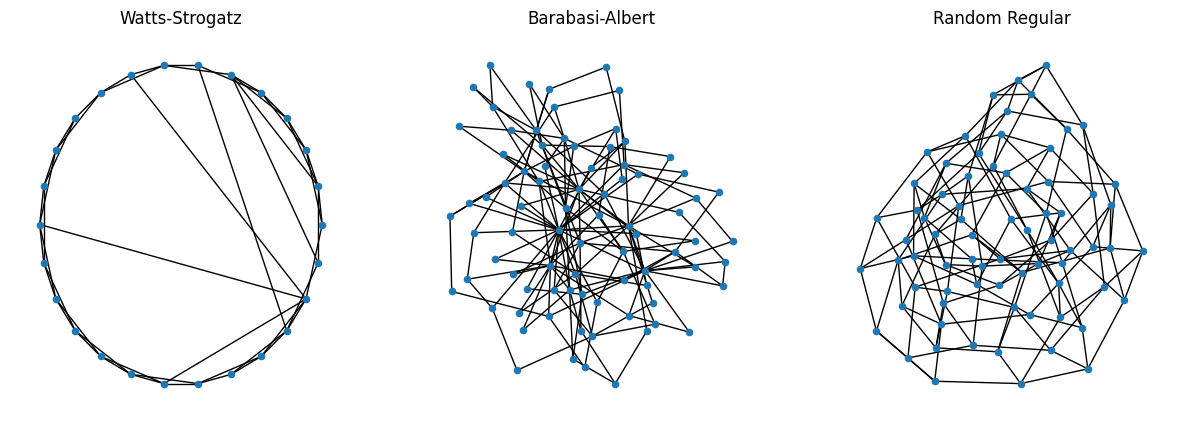

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

fig, axs = plt.subplots(1, 3, figsize=(15,5))

# Watts-Strogatz
G_ws = nx.watts_strogatz_graph(
    n=random.randint(20, 100),
    k=4,
    p=0.2
)

nx.draw(
    G_ws,
    pos=nx.circular_layout(G_ws),
    ax=axs[0],
    node_size=20
)

axs[0].set_title("Watts-Strogatz")


# Barabasi-Albert
G_ba = nx.barabasi_albert_graph(
    n=random.randint(20, 100),
    m=2
)

nx.draw(
    G_ba,
    pos=nx.spring_layout(G_ba),
    ax=axs[1],
    node_size=20
)

axs[1].set_title("Barabasi-Albert")


# Random Regular
G_rr = nx.random_regular_graph(
    d=4,
    n=random.randint(20, 100)
)

nx.draw(
    G_rr,
    pos=nx.spring_layout(G_rr),
    ax=axs[2],
    node_size=20
)

axs[2].set_title("Random Regular")

plt.show()

## Convert to PyTorch geometric

### create node features

In [ ]:
def create_node_features(G):

    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    betweenness = nx.betweenness_centrality(G)

    x = []

    for node in G.nodes():

        x.append([
            degrees[node],
            clustering[node],
            betweenness[node]
        ])

    return torch.tensor(x, dtype=torch.float)



def graph_to_data(G, label):

    data = from_networkx(G)
    data.x = create_node_features(G)
    data.y = torch.tensor([label], dtype=torch.long)

    return data


# G = generate_watts_strogatz(30)
# data = graph_to_data(G_ws, 0)

# print(data)
# print(data.x.shape)
# print(data.edge_index.shape)

### build dataset

In [ ]:
def generate_dataset(num_graphs_per_class=500):

    dataset = []

    for _ in range(num_graphs_per_class):

        # Watts-Strogatz
        G = generate_watts_strogatz(
            np.random.randint(20, 100)
        )

        dataset.append(graph_to_data(G, 0))


        # Barabasi-Albert
        G = generate_barabasi_albert(
            np.random.randint(20, 100)
        )

        dataset.append(graph_to_data(G, 1))


        # Random Regular
        G = generate_random_regular(
            np.random.randint(20, 100)
        )

        dataset.append(graph_to_data(G, 2))

    return dataset

### generate dataset

In [ ]:
dataset = generate_dataset(500)

print(len(dataset))

print(dataset[0])
print(dataset[100])

1500
Data(edge_index=[2, 388], num_nodes=62, x=[62, 3], y=[1])
Data(edge_index=[2, 482], num_nodes=80, x=[80, 3], y=[1])


## training and test splits

In [ ]:
train, test = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
train_loader = DataLoader(
    train,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test,
    batch_size=32
)

In [ ]:
batch = next(iter(train_loader))
print(batch)

DataBatch(edge_index=[2, 12272], num_nodes=2013, x=[2013, 3], y=[32], batch=[2013], ptr=[33])


# GAT

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear

from torch_geometric.nn import GATConv
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import global_add_pool
from torch_geometric.nn import BatchNorm

In [ ]:
class GAT(torch.nn.Module):

    def __init__(self):

        super().__init__()

        # Attention layers
        self.conv1 = GATConv(
            3,
            64,
            heads=4
        )

        self.conv2 = GATConv(
            64 * 4,
            64,
            heads=4
        )

        self.conv3 = GATConv(
            64 * 4,
            64,
            heads=1
        )

        # BatchNorm
        self.bn1 = BatchNorm(64 * 4)
        self.bn2 = BatchNorm(64 * 4)
        self.bn3 = BatchNorm(64)

        # Final classifier
        self.lin = Linear(64, 3)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        x = global_add_pool(x, batch)

        x = self.lin(x)

        return x

### initialize model

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT().to(device)

### training function

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

loss_function = torch.nn.CrossEntropyLoss()

### training function

In [ ]:
def train():

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        out = model(
            data.x,
            data.edge_index,
            data.batch
        )

        loss = loss_function(out, data.y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss

### evaluation function

In [ ]:
def test(loader):

    model.eval()

    correct = 0

    for data in loader:

        data = data.to(device)

        out = model(
            data.x,
            data.edge_index,
            data.batch
        )

        pred = out.argmax(dim=1)

        correct += int((pred == data.y).sum())

    return correct / len(loader.dataset)

### run model

In [ ]:
train_accs = []
test_accs = []
losses = []

best_test_acc = 0
best_epoch = 0

for epoch in range(1, 51):

    loss = train()

    train_acc = test(train_loader)

    test_acc = test(test_loader)

    # appends
    losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Save best model
    if test_acc > best_test_acc:

        best_test_acc = test_acc
        best_epoch = epoch

        # torch.save(
        #     model.state_dict(),
        #     "best_gat.pt"
        # )

    print(
        f"Epoch {epoch:3d} | "
        f"Loss {loss:.3f} | "
        f"Train {train_acc:.3f} | "
        f"Test {test_acc:.3f}"
    )

print("\nBest Test Accuracy:", best_test_acc)
print("Best Epoch:", best_epoch)

Epoch   1 | Loss 61.019 | Train 0.905 | Test 0.890
Epoch   2 | Loss 7.774 | Train 0.943 | Test 0.937
Epoch   3 | Loss 6.238 | Train 0.968 | Test 0.957
Epoch   4 | Loss 6.509 | Train 0.976 | Test 0.963
Epoch   5 | Loss 6.059 | Train 0.982 | Test 0.973
Epoch   6 | Loss 6.261 | Train 0.983 | Test 0.977
Epoch   7 | Loss 3.855 | Train 0.984 | Test 0.977
Epoch   8 | Loss 3.255 | Train 0.992 | Test 0.977
Epoch   9 | Loss 3.763 | Train 0.983 | Test 0.980
Epoch  10 | Loss 3.348 | Train 0.991 | Test 0.980
Epoch  11 | Loss 3.701 | Train 0.981 | Test 0.970
Epoch  12 | Loss 4.390 | Train 0.991 | Test 0.980
Epoch  13 | Loss 2.972 | Train 0.989 | Test 0.980
Epoch  14 | Loss 2.281 | Train 0.990 | Test 0.983
Epoch  15 | Loss 1.930 | Train 0.994 | Test 0.987
Epoch  16 | Loss 2.716 | Train 0.990 | Test 0.990
Epoch  17 | Loss 2.179 | Train 0.996 | Test 0.993
Epoch  18 | Loss 2.725 | Train 0.995 | Test 0.990
Epoch  19 | Loss 2.921 | Train 0.989 | Test 0.983
Epoch  20 | Loss 2.407 | Train 0.997 | Test 0.993

# Plots

## accuracy plot

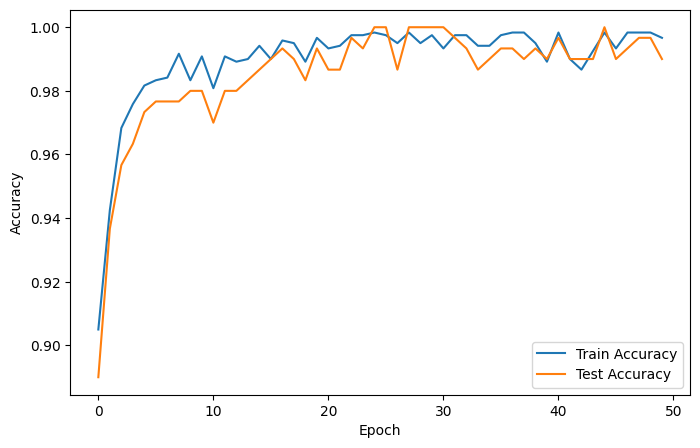

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

### loss plot

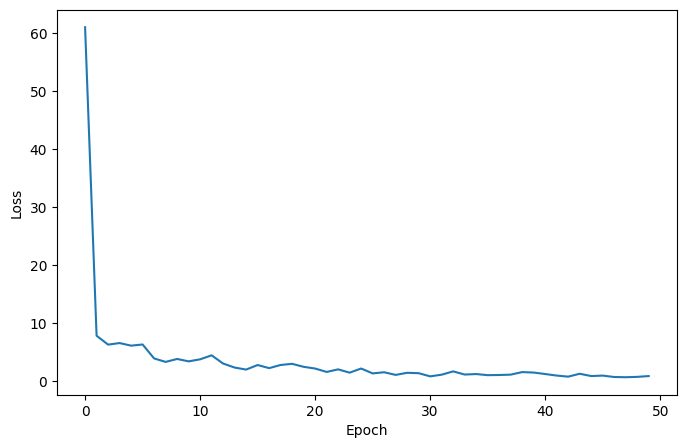

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

### confusion matrix

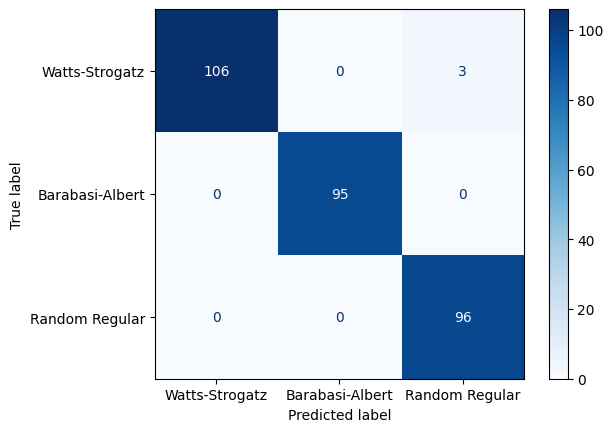

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


y_true = []
y_pred = []

model.eval()

for data in test_loader:

    data = data.to(device)

    out = model(
        data.x,
        data.edge_index,
        data.batch
    )

    pred = out.argmax(dim=1)

    y_true.extend(data.y.cpu().numpy())
    y_pred.extend(pred.cpu().numpy())


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Watts-Strogatz",
        "Barabasi-Albert",
        "Random Regular"
    ]
)

disp.plot(cmap="Blues")

plt.show()